In [11]:
cd tumbling_git/

[Errno 2] No such file or directory: 'tumbling_git/'
/share/nas2/pryder/tumbling_git


In [ ]:
# %matplotlib widget
from unpack_vdif import unpacksamps, sortframes, readframes, readheader
import numpy as np
from scipy.fft import fft, ifft
import matplotlib.pyplot as plt
from datetime import datetime
from datetime import timedelta
from scipy.ndimage import shift
from schedule_utils import range_finder_general
from skyfield.api import load, EarthSatellite, wgs84
# %load_ext jupyternotify
from scipy.signal import find_peaks
from scipy.ndimage import shift as imshift
from pc_utils import rect, signal_samp_to_dB
from scipy.signal import ShortTimeFFT, stft
from scipy.signal.windows import gaussian


In [13]:
#inputting tle
tle_line_1 = '1 40731U 15033B   26046.96407114  .00000009  00000-0  00000+0 0  9995'
tle_line_2 = '2 40731  54.6696 288.5525 0237286   9.2718 351.2385  1.90866878 73834'
ts = load.timescale()
atlas_tle = EarthSatellite(tle_line_1, tle_line_2, 'atlas', ts)

In [ ]:
#input paramters
f1 = int(0)        
bw = int(8e6)        
Tp = 800e-6    
pri = 20.506e-3 
freq = 1295e6
c= 299792458
samp_rate = 16e6
alpha = bw/Tp   #chirp rate
N = 100
infilename = '/share/nas2/pryder/realtime_test_1/vdifs/SD20003_20260218_mk2_1295MHz_atlasrb.vdif'

In [5]:
#opens vdif
with open(infilename) as infile:
    header = readheader(infile)
    framedata, seconds, framenums, threads = readframes(infile, header)

threaddata = sortframes(framedata, seconds, framenums, threads)
pola = unpacksamps(threaddata[0,:], header['nbits'], header['dtype'])

#### Converting real samples to IQ

In [6]:
# Convert to IQ. Add a phase that rotates every 4 samples
phase_4_samples = np.array([ 1+0j, 0-1j, -1+0j, 0+1j ])
phase_all_samples = np.tile(phase_4_samples, pola.size//4+1)  # +1 in case not divisible by 4
iq_samples_not_down = pola*phase_all_samples[:pola.size]

#### Real Samples

In [23]:
points = int(samp_rate*pri) #number of samples per pulse

height = 128 #coherent processing interval

reduced_length = height*points #length for cpi that includes an integer number of pulses
padded_length = points + 2048
startoffset = int(samp_rate*100)
pola_reduced = iq_samples_not_down[startoffset:startoffset+reduced_length]
dat = pola_reduced.reshape((height, points))
# dat = dat.astype(float)-1.5
# dat = dat - np.mean(dat, axis=1, keepdims=True)
# cdat = dat.astype(complex)
cdat_pc = np.zeros((height, points), dtype=complex)

In [8]:
ts = load.timescale()
t_tle = ts.utc(2026, 2, 18, 14, 50)
range_rate_from_tle = range_finder_general(atlas_tle, t_tle, 'mark')[1]

In [9]:
tau_dot = range_rate_from_tle/c #normalised range rate
k = np.arange(points)

In [10]:
t1=np.linspace(0,pri,points,endpoint=False)

baseband_offset_term = np.exp(-2j*np.pi*f1*t1*tau_dot)

chirp_term= np.exp(1j*np.pi*alpha*t1**2*(1-tau_dot)**2) 

envelope_term = rect((t1)/(Tp*(1+tau_dot)))
window = np.hanning(points)
template = baseband_offset_term*chirp_term*envelope_term

In [47]:
for i in range(height):
     start_sec=i*pri
     end_sec=(i+1)*pri
     t=np.linspace(start_sec,end_sec,points,endpoint=False)
     received_pulse=dat[i]
     phase_ramp=np.exp(2j*np.pi*freq*(t+tau_dot+(Tp/2))) #doppler phase correction
     signal1_fft = np.fft.fft(received_pulse)
     signal2_fft = np.fft.fft(template)
     correlation2 = np.fft.ifft(signal1_fft * signal2_fft.conjugate()*phase_ramp)
     #tried to implement digital timing correction (to align peak within centre of sample) but it did not work - needs more thought
    #  correlation2_in_fd = np.fft.fft(correlation2)
    #  timing_difference = estimate_delta_phase(correlation2, samp_rate)
    #  digital_timing = np.exp(2j*np.pi*k*samp_rate*timing_difference) #peak not centred in discrete time interval correction
    #  correlation3 = correlation2_in_fd * digital_timing
    #  correlation3 = np.fft.ifft(correlation3)
     cdat_pc[i,:]=correlation2

KeyboardInterrupt: 

In [ ]:
# getting original signal and spectrum

#inputting tle
tle_line_1 = '1 40731U 15033B   26046.96407114  .00000009  00000-0  00000+0 0  9995'
tle_line_2 = '2 40731  54.6696 288.5525 0237286   9.2718 351.2385  1.90866878 73834'
ts = load.timescale()
atlas_tle = EarthSatellite(tle_line_1, tle_line_2, 'atlas', ts)

#input paramters
f1 = int(0)        
bw = int(8e6)        
Tp = 800e-6    
pri = 20.506e-3 
freq = 1295e6
c= 299792458
samp_rate = 16e6
alpha = bw/Tp   #chirp rate
N = 100
infilename = '/share/nas2/pryder/realtime_test_1/vdifs/SD20003_20260218_mk2_1295MHz_atlasrb.vdif'

#opens vdif
with open(infilename) as infile:
    header = readheader(infile)
    framedata, seconds, framenums, threads = readframes(infile, header)
threaddata = sortframes(framedata, seconds, framenums, threads)
pola = unpacksamps(threaddata[0,:], header['nbits'], header['dtype'])
print('VDIF opened.')

# Convert to IQ. Add a phase that rotates every 4 samples
phase_4_samples = np.array([ 1+0j, 0-1j, -1+0j, 0+1j ])
phase_all_samples = np.tile(phase_4_samples, pola.size//4+1)  # +1 in case not divisible by 4
iq_samples_not_down = pola*phase_all_samples[:pola.size]
print('Converted into IQ samples.')

# reshaping into pulse repetition intervals
points = int(samp_rate*pri) #number of samples per pulse
height = 128 #coherent processing interval
reduced_length = height*points #length for cpi that includes an integer number of pulses
startoffset = int(samp_rate*100)
pola_reduced = iq_samples_not_down[startoffset:startoffset+reduced_length]
dat = pola_reduced.reshape((height, points))
cdat_pc = np.zeros((height, points), dtype=complex)

#getting range rate for template pulse
ts = load.timescale()
t_tle = ts.utc(2026, 2, 18, 14, 50)
range_rate_from_tle = range_finder_general(atlas_tle, t_tle, 'mark')[1]
tau_dot = range_rate_from_tle/c #normalised range rate
k = np.arange(points)

#making template pulse
t1=np.linspace(0,pri,points,endpoint=False)
baseband_offset_term = np.exp(-2j*np.pi*f1*t1*tau_dot)
chirp_term= np.exp(1j*np.pi*alpha*t1**2*(1-tau_dot)**2) 
envelope_term = rect((t1)/(Tp*(1+tau_dot)))
template = baseband_offset_term*chirp_term*envelope_term
print('Template pulse made.')

#doing pulse compression
for i in range(height):
     start_sec=i*pri
     end_sec=(i+1)*pri
     t=np.linspace(start_sec,end_sec,points,endpoint=False)
     received_pulse=dat[i]
     phase_ramp=np.exp(2j*np.pi*freq*(t+tau_dot+(Tp/2))) #doppler phase correction
     signal1_fft = np.fft.fft(received_pulse)
     signal2_fft = np.fft.fft(template)
     correlation2 = np.fft.ifft(signal1_fft * signal2_fft.conjugate()*phase_ramp)
     cdat_pc[i,:]=correlation2
print('Pulse compression complete')

power = (np.abs(cdat_pc))**2
spectrum = np.sum(power, axis=0)

freqs = np.fft.fftshift(np.fft.fftfreq(points, (1/samp_rate)))
print('Finished')

In [32]:
power = (np.abs(cdat_pc))**2
spec = np.sum(power, axis=0)

spec_dB = signal_samp_to_dB(power, spec)
power_dB = signal_samp_to_dB(power, power)

## Uncorrected Incoherent Sum and RTI

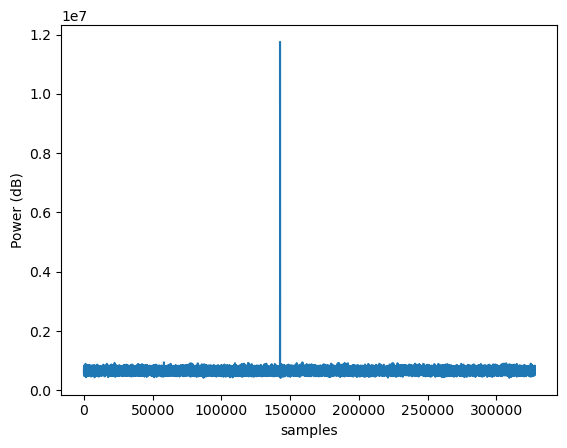

In [33]:
# complete incoherent sum
plt.plot(spec, label='Ch 0')
plt.xlabel('samples')
plt.ylabel('Power (dB)')
plt.show()

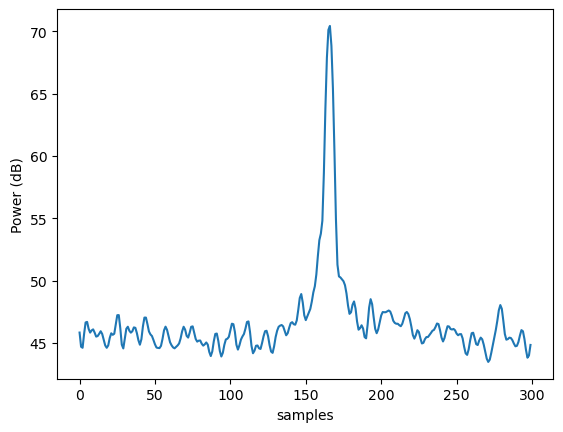

In [38]:
#incoherent sum
plt.plot(spec_dB[142500:142800], label='Ch 0')
plt.xlabel('samples')
plt.ylabel('Power (dB)')
plt.show()

In [ ]:
#incoherent sum - but make sure you check which channel you've put in , need to see which is better 
plt.plot(spec_dB[140000:144000], label='Ch 1')
plt.xlabel('samples')
plt.ylabel('Power (dB)')
plt.show()

In [25]:
noise = np.median(power)
signal = power/noise
signal_dB = 20*np.log10(signal)

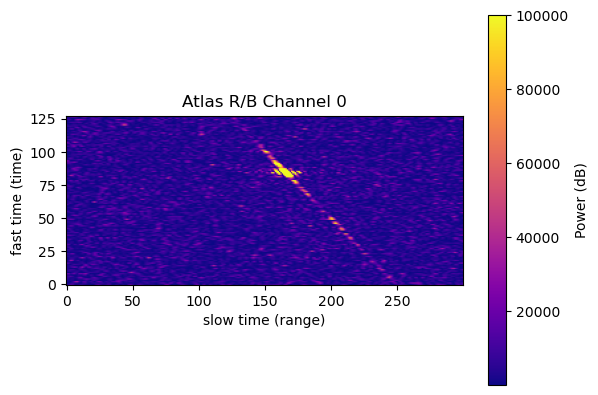

In [43]:
#rti
plt.imshow(power[:, 142500:142800], vmax=1e5, cmap = 'plasma', origin='lower')
plt.title('Atlas R/B Channel 0')
cbar= plt.colorbar()
cbar.set_label('Power (dB)', rotation=90)
plt.xlabel('slow time (range)')
plt.ylabel('fast time (time)')
plt.show()

## Range Migration Corrections

In [ ]:
r_i = []
#this is the first correction
sub_power = power[:, 140000:144000]
time1 = np.arange(sub_power.shape[0])
data = sub_power.T

r = np.zeros(data.shape[1], dtype=int)
r[0] = np.argmax(np.abs(data[:, 1]))

window = 10

for i in range(1, data.shape[1]):
    prev = r[i-1]
    
    start = max(0, prev - window)
    end = min(data.shape[0], prev + window)
    segment = np.abs(data[start:end, i])
    print(i)

    #local maximum
    r[i] = start + np.argmax(segment)
   

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
277


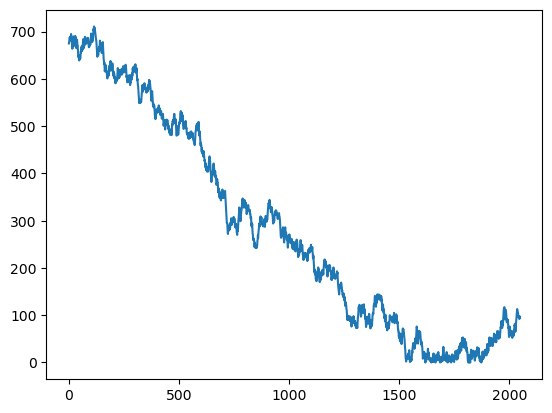

In [55]:
#plotting range per pulse 
plt.plot(time1, r)
plt.show()

#### Averaging pulses together

In [ ]:
segment.shape # need to make sure we're doing this right

(20,)

In [120]:
r_i = []
sub_power = power[:, 140000:144000]
time1 = np.arange(sub_power.shape[0])
data = sub_power.T

r = np.zeros(data.shape[1], dtype=int)
r[0] = np.argmax(np.abs(data[:, 1]))

window = 10

num_pulses_combined = 6

avgd_length = int(data.shape[1]/num_pulses_combined)
j=0
for i in range(1, avgd_length):
    print(j)
    prev = r[i-1]
    
    start = max(0, prev - window)
    end = min(data.shape[0], prev + window)
    pre_segment = data[start:end, j:j+num_pulses_combined]
    segment = np.abs(np.average(pre_segment, axis=1))

    #local maximum
    r[i] = start + np.argmax(segment)
    j+=num_pulses_combined

0
6
12
18
24
30
36
42
48
54
60
66
72
78
84
90
96
102
108
114
120
126
132
138
144
150
156
162
168
174
180
186
192
198
204
210
216
222
228
234
240
246
252
258
264
270
276
282
288
294
300
306
312
318
324
330
336
342
348
354
360
366
372
378
384
390
396
402
408
414
420
426
432
438
444
450
456
462
468
474
480
486
492
498
504
510
516
522
528
534
540
546
552
558
564
570
576
582
588
594
600
606
612
618
624
630
636
642
648
654
660
666
672
678
684
690
696
702
708
714
720
726
732
738
744
750
756
762
768
774
780
786
792
798
804
810
816
822
828
834
840
846
852
858
864
870
876
882
888
894
900
906
912
918
924
930
936
942
948
954
960
966
972
978
984
990
996
1002
1008
1014
1020
1026
1032
1038
1044
1050
1056
1062
1068
1074
1080
1086
1092
1098
1104
1110
1116
1122
1128
1134
1140
1146
1152
1158
1164
1170
1176
1182
1188
1194
1200
1206
1212
1218
1224
1230
1236
1242
1248
1254
1260
1266
1272
1278
1284
1290
1296
1302
1308
1314
1320
1326
1332
1338
1344
1350
1356
1362
1368
1374
1380
1386
1392
1398
1404
1410
1416
1

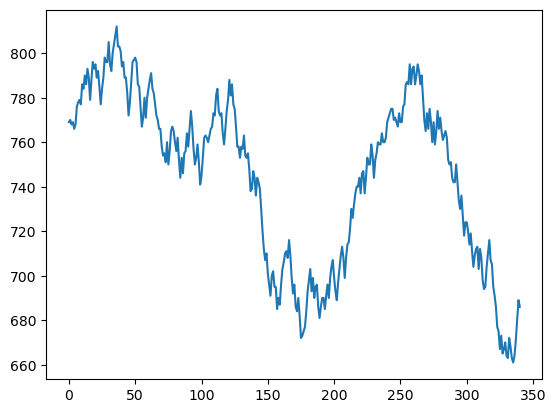

In [ ]:
#plotting range per pulse type 
plt.plot(time1[0:341], r[0:341])
plt.show()

In [ ]:
#expanding average correction to be correction for every pulse
r_expanded = []
for x in r[0:avgd_length]:
    for y in range(num_pulses_combined):
        r_expanded.append(x)

for z in range(2048-len(r_expanded)):
    r_expanded.append(x)

In [ ]:
len(r_expanded)

2048

#### Fitting motion compensation

In [ ]:
coeffs = np.polyfit(time1, r_expanded, 8)   #2 is quadratic fit, 8 is ridiculous!
r_fit = np.polyval(coeffs, time1)

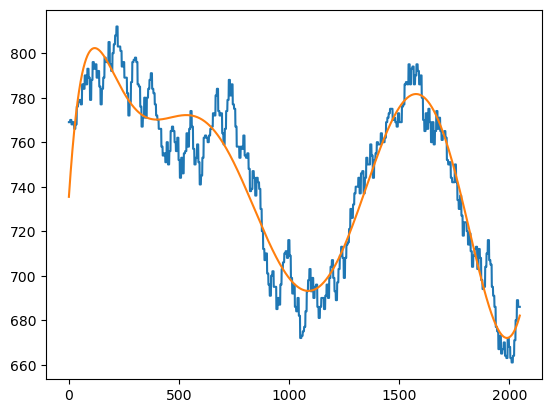

In [144]:
# %matplotlib inline
#plotting fit
plt.plot(time1, r_expanded)
plt.plot(time1, r_fit)
plt.show()

In [145]:
r_ref = r_fit[len(r_fit)//2]
rmc_shift = r_fit-r_ref

In [146]:
#takes about 3 minutes
corrected = np.zeros_like(cdat_pc)
for i in range(2048):
    corrected[i, :] = imshift(cdat_pc[i, :], -rmc_shift[i])

In [147]:
power_corrected = (np.abs(corrected))**2
spec_corrected = np.sum(power_corrected, axis=0)

distribution is 1535


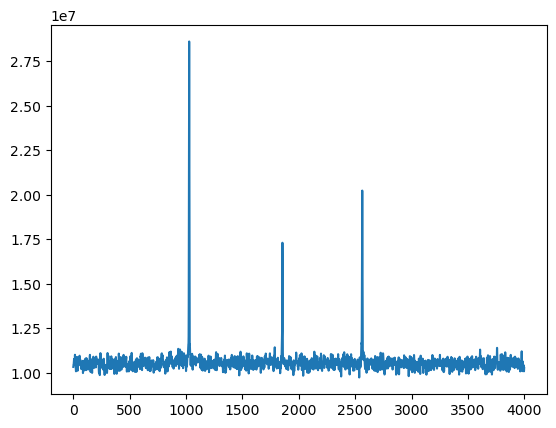

In [149]:
peaks, _ = find_peaks(spec_corrected, 1.5e7)
print('distribution is', peaks[-1]-peaks[0])
# plt.plot(spec_corrected[134000:139000], label='Ch 0')
plt.plot(spec_corrected[140000:144000], label='Ch 0')
# plt.hlines((np.max(spec_corrected)-np.min(spec_corrected))/1.5, 0, 10000)
plt.show()

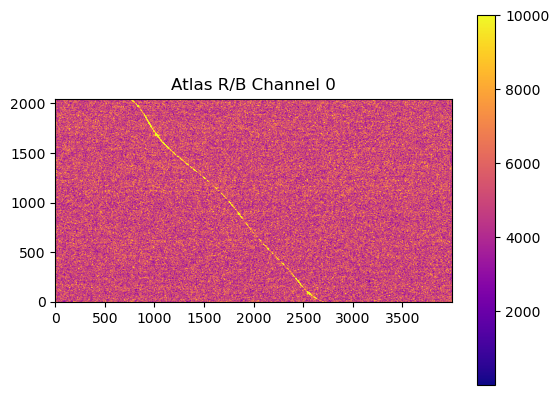

In [150]:
plt.imshow(power_corrected[:, 140000:144000], vmax = 10000, cmap = 'plasma', origin='lower')
plt.title('Atlas R/B Channel 0')
plt.colorbar()
plt.show()

#### Creating example corrected array

In [ ]:
base_noise = np.zeros_like(cdat_pc)
for i in range(3000):
    base_noise[:, i] = random.sample(range(1, 6000), 2048)

base_noise[:, 810] = [100000]*2048

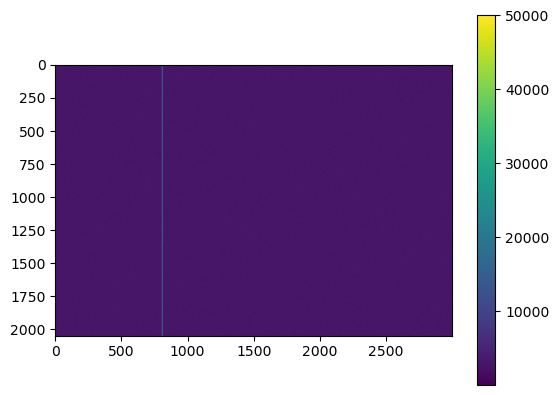

In [140]:
plt.imshow(base_noise, vmax=50000)
plt.colorbar()
plt.show()

#### Making this per pulse range fitting process iterative

Currently this is to loop using the previous correction and then correcting that further. Not only does that not make sense physically, it doesn't improve anything. Needs to be edited to find best fit parameters.

In [ ]:
distribution_init = 842
for j in range(10):
    r_i = []
    sub_power = power[:, 134000:137000]
    data = sub_power.T

    r = np.zeros(data.shape[1], dtype=int)
    r[0] = np.argmax(np.abs(data[:, 1]))

    window = 10 

    for i in range(1, data.shape[1]):
        prev = r[i-1]
        
        start = max(0, prev - window)
        end = min(data.shape[0], prev + window)
        segment = np.abs(data[start:end, i])

        #local maximum
        r[i] = start + np.argmax(segment)
    
    coeffs = np.polyfit(time1, r, 2)   #quadratic fit
    r_fit = np.polyval(coeffs, time1)
    r_ref = r_fit[len(r_fit)//2]
    rmc_shift = r_fit-r_ref
    corrected = np.zeros_like(cdat_pc)
    for k in range(2048):
        corrected[k, :] = imshift(cdat_pc[k, :], -rmc_shift[k])

    power_corrected = (np.abs(corrected))**2
    spec_corrected = np.sum(power_corrected, axis=0)
    rough_threshold = (np.max(spec_corrected)-np.min(spec_corrected))/1.5
    peaks, _ = find_peaks(spec_corrected, rough_threshold)
    if len(peaks)<2:
        print('youve either done really well, or youve got the wrong threshold')

    else:
        distribution = peaks[-1]-peaks[0]
        print(distribution)
    
    if 
    
    

    


    
    

1245
1191
885
1396
1212
968
1337
989
1269
923


## Microdoppler Spectrogram

In [ ]:
height = 128 #coherent processing interval

reduced_length = height*points 

t1=np.linspace(0,pri,points,endpoint=False)

baseband_offset_term = np.exp(-2j*np.pi*f1*t1*tau_dot)

chirp_term= np.exp(1j*np.pi*alpha*t1**2*(1-tau_dot)**2) 

envelope_term = rect((t1)/(Tp*(1+tau_dot)))

In [21]:
cpi_jump_samples = int(reduced_length)

# if doing successive cpis, this is the maximum number of strips you can get in your spectrogram
# now edited so it will be universal max (i think) - but for small increments this will be very large - don't run 10 million!
n_max_successive = int(np.floor((len(pola) - startoffset - 1- reduced_length)/reduced_length))
n_max_window = int(np.floor((len(pola)-startoffset-reduced_length)/cpi_jump_samples))

# if doing one sample difference, then n_max is very large 

number_of_strips_in_spectrogram = n_max_window

spectrogram = np.zeros((height, number_of_strips_in_spectrogram))
peak_range_history = []
peak_doppler_history = []

In [26]:
# %%notify -m "Spectrogram generated..."
#looping over successive cpis to generate spectrogram
for n in range(number_of_strips_in_spectrogram):
    print("strip ", n, " of ", number_of_strips_in_spectrogram)
    # start_index = startoffset + (n*reduced_length)
    # end_index = startoffset + ((n+1)*reduced_length)
    start_index = cpi_jump_samples*n + startoffset
    end_index = cpi_jump_samples*(n+1)+ reduced_length + startoffset - cpi_jump_samples

    print('which covers samples ', start_index, " to ", end_index)
    pola_reduced = iq_samples_not_down[start_index:end_index]
    dat = pola_reduced.reshape((height, points))
    cdat_pc = np.zeros_like(dat)

    for i in range(height):
     start_sec=i*pri
     end_sec=(i+1)*pri
     t=np.linspace(start_sec,end_sec,points,endpoint=False)
     received_pulse=dat[i]
     phase_ramp=np.exp(2j*np.pi*freq*(t+tau_dot+(Tp/2))) #doppler phase correction
     signal1_fft = np.fft.fft(received_pulse)
     signal2_fft = np.fft.fft(template)
     correlation2 = np.fft.ifft(signal1_fft * signal2_fft.conjugate()*phase_ramp)
     cdat_pc[i,:]=correlation2


    print('Finished pulse compression')
    unshifted_range_doppler = np.fft.fft(cdat_pc, axis=0)
    range_doppler = np.fft.fftshift(unshifted_range_doppler, axes=0)
    rd_abs = np.abs(range_doppler ** 2)
    rd_abs_reduced = rd_abs[:, :]
    peaks = np.sum(rd_abs_reduced, axis = 0)
    peak = np.argmax(peaks)
    strip = rd_abs_reduced[:, peak:peak+1]
    print('Peak index: ', peak)
    # print(spectrogram[:, n:n+1])
    spectrogram[:, n:n+1] = strip
    peak_range_history.append(peak)
    # print(strip)
    # print(spectrogram[:, n:n+1])

strip  0  of  62
which covers samples  1600000000  to  1641996288
Finished pulse compression
Peak index:  142666
strip  1  of  62
which covers samples  1641996288  to  1683992576
Finished pulse compression
Peak index:  245795
strip  2  of  62
which covers samples  1683992576  to  1725988864
Finished pulse compression
Peak index:  58302
strip  3  of  62
which covers samples  1725988864  to  1767985152
Finished pulse compression
Peak index:  281234
strip  4  of  62
which covers samples  1767985152  to  1809981440
Finished pulse compression
Peak index:  327363
strip  5  of  62
which covers samples  1809981440  to  1851977728
Finished pulse compression
Peak index:  173965
strip  6  of  62
which covers samples  1851977728  to  1893974016
Finished pulse compression
Peak index:  141880
strip  7  of  62
which covers samples  1893974016  to  1935970304
Finished pulse compression
Peak index:  294572
strip  8  of  62
which covers samples  1935970304  to  1977966592
Finished pulse compression
Peak

: 

: 

: 

In [15]:
import scipy.signal as ss

In [16]:
window = ss.get_window('boxcar', points)

In [25]:
unshifted_range_doppler = ss.ShortTimeFFT(window, 2, samp_rate, fft_mode='twosided', mfft=padded_length).stft(cdat_pc)

KeyboardInterrupt: 

In [ ]:
#only needed to save numpy array
np.save('./atlas_64overlap.npy', spectrogram)
#only needed if loading in previously saved spectrogram array
spectrogram = np.load('atlas_64overlap.npy')

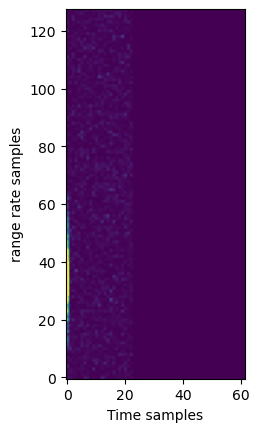

In [19]:
plt.imshow(spectrogram[:, :], vmax=3e7, origin='lower')#, extent = [time_labels[0], time_labels[-1], 0, 19], aspect='auto')
plt.xlabel('Time samples')
plt.ylabel ('range rate samples')
# plt.vlines((80, 92), 0, 39, 'r')
# plt.colorbar()
plt.show()